# Detecção de fissuras superficiais em concreto — CNN baseline e transfer learning

### Autor: Lucca Maximus Romagnolli Soares — Universidade de Brasília

## Problema de negócio e impacto

A inspeção visual de superfícies de concreto para identificar **fissuras** é repetitiva e dependente do inspetor. Um classificador por imagem pode **priorizar pontos de manutenção**, padronizar critérios e apoiar manutenção preditiva.

## Objetivo técnico (resumo)

- **Treinar** um classificador binário (superfície **sem fissura** *vs.* **com fissura**) com **CNN baseline** e **transfer learning** (backbone ImageNet).
- **Garantir reprodutibilidade** (seeds, configuração centralizada, registro de ambiente).
- **Gerar artefatos**: modelo salvo, métricas em CSV e inferência em imagem nova.

## Abordagem

- Baseline: CNN leve treinada do zero em imagens 128×128, RGB normalizado em **[0, 1]**.
- Transfer: **MobileNetV2** (alternativa **EfficientNetB0** no `CONFIG`).
- Treino em **duas fases**: cabeça com backbone congelado; depois *fine-tuning* com taxa menor.

**Dataset:** pastas `Negative` (sem fissura) e `Positive` (com fissura) em `datasets/surface-crack-detection/`. O volume total pode ser grande; use `MAX_IMAGENS_POR_CLASSE` no `CONFIG` para subamostragem reprodutível.


## Diagnóstico do estado anterior (referência do projeto *whole-detection*)

O notebook de buracos em pavimento estabeleceu o mesmo desenho experimental:

| Aspecto | Situação de referência |
|--------|----------|
| **Arquitetura baseline** | Blocos `Conv2D→MaxPool` até `Dense(1, sigmoid)` |
| **Transfer** | Backbone ImageNet + GAP → Dropout → Dense → softmax |
| **Pré-processamento baseline** | Resize 128×128, RGB, **[0, 1]** |
| **Transfer** | Augmentation no treino + `preprocess_input` do backbone |
| **Split** | 80/20 estratificado, `random_state` fixo |

Este notebook **replica o fluxo** para fissuras, usando `src/deteccao_fissuras.py` e os utilitários de transferência em `src/deteccao_buracos_transfer.py`.


## Configuração

Sementes globais, dicionário `CONFIG`, criação de pastas (`data/`, `models/`, `logs/`, `outputs/`) e registro de versões de bibliotecas.

**Dependências:** OpenCV (`cv2`). Há uma célula que instala `opencv-python` neste kernel se faltar.


In [1]:
# Reprodutibilidade: seeds e determinismo (GPU pode manter pequena variância).
import os
import random

import numpy as np
import tensorflow as tf


def configurar_sementes_globais(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass


In [2]:
from pathlib import Path
from types import SimpleNamespace

_raiz_atual = Path.cwd().resolve()
PROJETO_RAIZ = next((p for p in [_raiz_atual, *_raiz_atual.parents] if (p / "src").exists()), _raiz_atual)

NOMES_CLASSES = ("sem_fissura", "com_fissura")

CONFIG = {
    "SEED": 42,
    "DATA_ROOT": PROJETO_RAIZ / "datasets",
    "IMG_SIZE": (128, 128),
    "BATCH_SIZE": 32,
    "EPOCHS_BASELINE": 10,
    "EPOCHS_HEAD": 30,
    "EPOCHS_FINETUNE": 30,
    "LR_HEAD": 1e-3,
    "LR_FINETUNE": 1e-5,
    "BACKBONE": "MobileNetV2",
    "UNFREEZE_LAYERS": 40,
    "EARLY_STOPPING_PATIENCE": 10,
    # Subamostragem por classe (None = carregar todas as imagens — pode exigir muita RAM)
    "MAX_IMAGENS_POR_CLASSE": 4000,
    "DEMO_IMAGE": None,
    "USE_GRADCAM": True,
    "DIR_DATA": PROJETO_RAIZ / "data",
    "DIR_MODELS": PROJETO_RAIZ / "models",
    "DIR_LOGS": PROJETO_RAIZ / "logs",
    "DIR_OUTPUTS": PROJETO_RAIZ / "outputs",
    "RESULTS_CSV": PROJETO_RAIZ / "outputs" / "results_surface_crack.csv",
    "CHECKPOINT_HEAD": PROJETO_RAIZ / "models" / "surface_crack_transfer_phase1_best.keras",
    "CHECKPOINT_FINETUNE": PROJETO_RAIZ / "models" / "surface_crack_transfer_phase2_best.keras",
}

for _d in (CONFIG["DIR_DATA"], CONFIG["DIR_MODELS"], CONFIG["DIR_LOGS"], CONFIG["DIR_OUTPUTS"]):
    _d.mkdir(parents=True, exist_ok=True)

CFG = SimpleNamespace(**CONFIG)
configurar_sementes_globais(CONFIG["SEED"])
print("PROJETO_RAIZ:", PROJETO_RAIZ)


PROJETO_RAIZ: /Users/luccaromagnolli/Desktop/Civil-Engineering


In [3]:
# Versões de ambiente (pip freeze filtrado — compatível com Colab).
import subprocess
import sys

_pkgs = (
    "tensorflow",
    "keras",
    "numpy",
    "pandas",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "opencv-python",
    "pillow",
    "jupyter",
)
try:
    out = subprocess.check_output([sys.executable, "-m", "pip", "freeze"], text=True, stderr=subprocess.STDOUT)
    for linha in out.splitlines():
        if any(linha.lower().startswith(p) for p in _pkgs):
            print(linha)
except Exception as e:
    print("pip freeze:", e)
print("Python:", sys.version)


jupyter_client @ file:///home/conda/feedstock_root/build_artifacts/jupyter_client_1733440914442/work
jupyter_core @ file:///home/conda/feedstock_root/build_artifacts/bld/rattler-build_jupyter_core_1760643864/work
keras==3.12.0
matplotlib==3.10.7
matplotlib-inline @ file:///home/conda/feedstock_root/build_artifacts/matplotlib-inline_1761214490209/work
numpy==2.3.5
pandas==2.3.3
pillow==12.0.0
scikit-learn==1.7.2
seaborn==0.13.2
tensorflow==2.20.0
TensorFlow1==3.2.0
Python: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:11:29) [Clang 20.1.8 ]


In [4]:
# Instala opencv-python no interpretador DESTE kernel (mesmo que sys.executable).
import subprocess
import sys

try:
    import cv2  # noqa: F401
    print("opencv-python já disponível (cv2 importou com sucesso).")
except ImportError:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "opencv-python"],
    )
    import cv2  # noqa: F401
    print("opencv-python instalado. Pode seguir para a célula de imports.")


opencv-python instalado. Pode seguir para a célula de imports.


In [5]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import roc_auc_score
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

if str(PROJETO_RAIZ) not in sys.path:
    sys.path.insert(0, str(PROJETO_RAIZ))

from src.deteccao_fissuras import (
    MAPA_CLASSES,
    PROPORCAO_VALIDACAO_PADRAO,
    SEMENTE_PADRAO,
    avaliar_modelo,
    carregar_imagens_rotuladas,
    construir_cnn_baseline,
    obter_caminhos_dataset,
    obter_cv2,
    separar_treino_validacao,
    treinar_modelo,
)
from src.deteccao_buracos_transfer import (
    MetricasValidacaoCallback,
    anexar_historico_csv,
    avaliar_modelo_softmax,
    calcular_class_weight_dict,
    congelar_backbone,
    construir_modelo_transfer_completo,
    descongelar_ultimas_camadas_backbone,
    grad_cam_mobilenet,
    montar_tf_dataset_treino,
    montar_tf_dataset_validacao,
    obter_preprocess_input,
    preprocess_numpy_rgb_01,
)

sns.set_theme(style="whitegrid")


## Dados

Carregamento a partir de `datasets/surface-crack-detection/Negative` e `Positive`. Imagens em **[0, 1]** no baseline; o modelo de transfer usa **augmentation** + **pré-processamento ImageNet** no `tf.data`.

Se `MAX_IMAGENS_POR_CLASSE` estiver definido, há **subamostragem reprodutível** por classe antes do *split* 80/20.


In [6]:
# Caminhos do dataset
caminhos = obter_caminhos_dataset(raiz_datasets=CONFIG["DATA_ROOT"])
print("Caminhos:", caminhos)

IMG_H, IMG_W = CONFIG["IMG_SIZE"]
TAMANHO = (IMG_H, IMG_W)

X, y = carregar_imagens_rotuladas(
    caminhos["base"],
    TAMANHO,
    max_por_classe=CONFIG["MAX_IMAGENS_POR_CLASSE"],
    semente_amostragem=CONFIG["SEED"],
)
print("X:", X.shape, "y:", y.shape, "min/max:", X.min(), X.max())
classes_unicas, contagens = np.unique(y, return_counts=True)
print("Distribuição:", dict(zip(classes_unicas.tolist(), contagens.tolist())))


Caminhos: {'base': '/Users/luccaromagnolli/Desktop/Civil-Engineering/datasets/surface-crack-detection', 'sem_fissura': '/Users/luccaromagnolli/Desktop/Civil-Engineering/datasets/surface-crack-detection/Negative', 'com_fissura': '/Users/luccaromagnolli/Desktop/Civil-Engineering/datasets/surface-crack-detection/Positive'}
X: (8000, 128, 128, 3) y: (8000,) min/max: 0.0 1.0
Distribuição: {0: 4000, 1: 4000}


/var/folders/0q/hw9t6jv16lq6_3f63snxhlrm0000gn/T/ipykernel_30925/856816679.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels_eda, y=valores, ax=axes[1], palette=["#2e8b57", "#cc3333"])


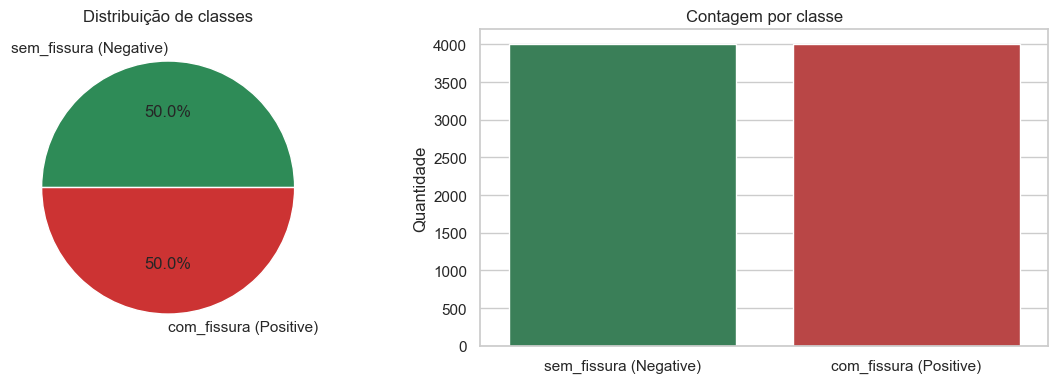

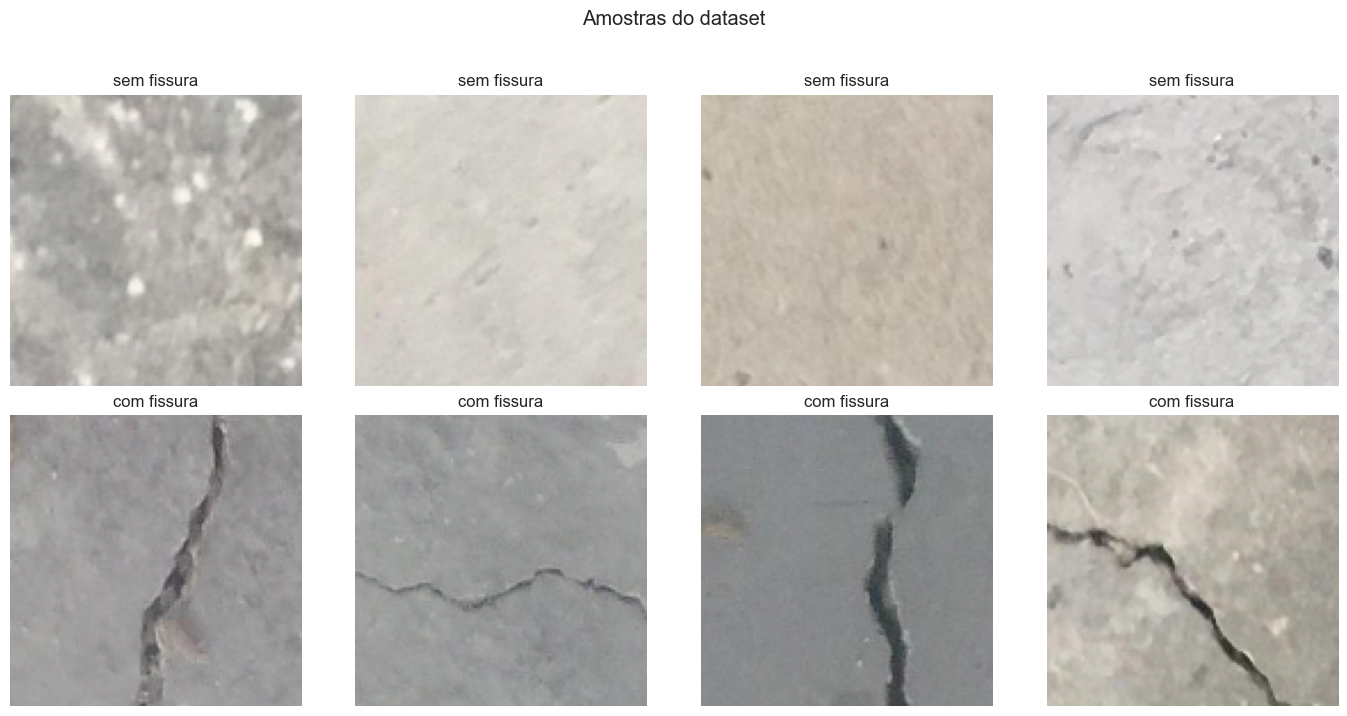

In [7]:
# EDA: distribuição e grade de amostras
labels_eda = ["sem_fissura (Negative)", "com_fissura (Positive)"]
valores = [int(np.sum(y == 0)), int(np.sum(y == 1))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].pie(valores, labels=labels_eda, autopct="%1.1f%%", colors=["#2e8b57", "#cc3333"])
axes[0].set_title("Distribuição de classes")
sns.barplot(x=labels_eda, y=valores, ax=axes[1], palette=["#2e8b57", "#cc3333"])
axes[1].set_title("Contagem por classe")
axes[1].set_ylabel("Quantidade")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
idx_n = np.where(y == MAPA_CLASSES["sem_fissura"])[0][:4]
idx_b = np.where(y == MAPA_CLASSES["com_fissura"])[0][:4]
for i, idx in enumerate(idx_n):
    axes[0, i].imshow(X[idx])
    axes[0, i].set_title("sem fissura")
    axes[0, i].axis("off")
for i, idx in enumerate(idx_b):
    axes[1, i].imshow(X[idx])
    axes[1, i].set_title("com fissura")
    axes[1, i].axis("off")
plt.suptitle("Amostras do dataset", y=1.02)
plt.tight_layout()
plt.show()


In [8]:
# Separação treino/validação (estratificada)
X_treino, X_valid, y_treino, y_valid = separar_treino_validacao(
    X, y, PROPORCAO_VALIDACAO_PADRAO, SEMENTE_PADRAO
)
print(X_treino.shape, X_valid.shape)

forma_entrada = (IMG_H, IMG_W, 3)
class_weights = calcular_class_weight_dict(y_treino)
print("class_weight:", class_weights)


(6400, 128, 128, 3) (1600, 128, 128, 3)
class_weight: {0: 1.0, 1: 1.0}


## Modelo — baseline (CNN do zero)

Referência para comparação com transfer learning. Mesma divisão treino/validação.


In [9]:
# Baseline: CNN *scratch* + treino com arrays NumPy
modelo_baseline = construir_cnn_baseline(forma_entrada)
historico_baseline = treinar_modelo(
    modelo_baseline,
    X_treino,
    y_treino,
    X_valid,
    y_valid,
    epocas=CONFIG["EPOCHS_BASELINE"],
    batch_size=CONFIG["BATCH_SIZE"],
)
resultados_baseline = avaliar_modelo(
    modelo_baseline, X_valid, y_valid, target_names=NOMES_CLASSES
)

f1_b = float(resultados_baseline["relatorio_classificacao"]["macro avg"]["f1-score"])
acc_b = float(resultados_baseline["acuracia"])
proba_b = np.asarray(resultados_baseline["probabilidades"], dtype=np.float64)
try:
    auc_b = float(roc_auc_score(y_valid, proba_b))
except ValueError:
    auc_b = float("nan")

metricas_baseline = {"accuracy": acc_b, "f1_macro": f1_b, "auc": auc_b}
print("Baseline:", metricas_baseline)


Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 23s 113ms/step - accuracy: 0.9306 - loss: 0.2007 - val_accuracy: 0.9794 - val_loss: 0.0636
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 22s 110ms/step - accuracy: 0.9794 - loss: 0.0839 - val_accuracy: 0.9881 - val_loss: 0.0429
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 22s 111ms/step - accuracy: 0.9841 - loss: 0.0617 - val_accuracy: 0.9906 - val_loss: 0.0384
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 24s 118ms/step - accuracy: 0.9850 - loss: 0.0552 - val_accuracy: 0.9906 - val_loss: 0.0351
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 26s 131ms/step - accuracy: 0.9881 - loss: 0.0409 - val_accuracy: 0.9900 - val_loss: 0.0362
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 24s 121ms/step - accuracy: 0.9900 - loss: 0.0382 - val_accuracy: 0.9919 - val_loss: 0.0336
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 23s 116ms/step - accuracy: 0.9931 - loss: 0.0253 - val_accuracy: 0.9919 - val_loss: 0.0226
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 24s 118ms/step - accuracy: 0.9902 - loss: 0

## Modelo — transfer learning (duas fases)

1. **Fase A:** backbone ImageNet **congelado**, treino do *head* (GAP → Dropout → Dense → softmax).
2. **Fase B:** **descongelar** as últimas `UNFREEZE_LAYERS` camadas, com `LR_FINETUNE` menor.

Pipeline: `tf.data` com augmentation apenas no treino.


## Treinamento

Duas fases com `EarlyStopping`, `ReduceLROnPlateau`, `ModelCheckpoint` e registro em `outputs/results_surface_crack.csv`.


In [10]:
# Fase A: backbone congelado + cabeça softmax
preprocess_tf = obter_preprocess_input(CONFIG["BACKBONE"])

ds_treino = montar_tf_dataset_treino(
    X_treino,
    y_treino,
    CONFIG["BATCH_SIZE"],
    preprocess_tf,
    CONFIG["SEED"],
)
ds_valid = montar_tf_dataset_validacao(
    X_valid,
    y_valid,
    CONFIG["BATCH_SIZE"],
    preprocess_tf,
)

modelo_tl, backbone = construir_modelo_transfer_completo(
    CONFIG["BACKBONE"],
    forma_entrada,
    n_classes=2,
    dropout=0.3,
    pesos="imagenet",
)
congelar_backbone(backbone)

modelo_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG["LR_HEAD"]),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

cb_metrics_1 = MetricasValidacaoCallback(
    X_valid, y_valid, "head", CONFIG["BACKBONE"], CONFIG["BATCH_SIZE"]
)
early = EarlyStopping(
    monitor="val_loss",
    patience=CONFIG["EARLY_STOPPING_PATIENCE"],
    restore_best_weights=True,
)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7)
ckpt1 = ModelCheckpoint(
    filepath=str(CONFIG["CHECKPOINT_HEAD"]),
    monitor="val_loss",
    save_best_only=True,
)

hist1 = modelo_tl.fit(
    ds_treino,
    epochs=CONFIG["EPOCHS_HEAD"],
    validation_data=ds_valid,
    class_weight=class_weights,
    callbacks=[early, reduce_lr, ckpt1, cb_metrics_1],
    verbose=1,
)
anexar_historico_csv(CONFIG["RESULTS_CSV"], cb_metrics_1.linhas, modo="w")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 28s 128ms/step - accuracy: 0.9920 - loss: 0.0266 - val_accuracy: 0.9962 - val_loss: 0.0160 - learning_rate: 0.0010 - val_f1: 0.9962 - val_auc: 0.9999
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 27s 134ms/step - accuracy: 0.9959 - loss: 0.0124 - val_accuracy: 0.9975 - val_loss: 0.0137 - learning_rate: 0.0010 - val_f1: 0.9975 - val_auc: 0.9999
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 27s 133ms/step - accuracy: 0.9981 - loss: 0.0068 - val_accuracy: 0.9981 - val_loss: 0.0103 - learning_rate: 0.0010 - val_f1: 0.9981 - val_auc: 0.9999
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 30s 150ms/step - accuracy: 0.9975 - loss: 0.0086 - val_accuracy: 0.9987 - val_loss: 0.0081 - learning_rate: 0.0010 - val_f1: 0.9988 - val_auc: 1.0000
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 29s 144ms/step - accuracy: 0.9978 - loss: 0.0073 - val_accuracy: 0.9981 - val_loss: 0.0104 - learning_rate: 0.0010 - val_f1: 0.9981 - val_auc: 1.0000
E

In [11]:
# Fase B: fine-tuning
modelo_tl.load_weights(str(CONFIG["CHECKPOINT_HEAD"]))
descongelar_ultimas_camadas_backbone(backbone, CONFIG["UNFREEZE_LAYERS"])

modelo_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG["LR_FINETUNE"]),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

cb_metrics_2 = MetricasValidacaoCallback(
    X_valid, y_valid, "finetune", CONFIG["BACKBONE"], CONFIG["BATCH_SIZE"]
)
early2 = EarlyStopping(
    monitor="val_loss",
    patience=CONFIG["EARLY_STOPPING_PATIENCE"],
    restore_best_weights=True,
)
reduce_lr2 = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-8)
ckpt2 = ModelCheckpoint(
    filepath=str(CONFIG["CHECKPOINT_FINETUNE"]),
    monitor="val_loss",
    save_best_only=True,
)

hist2 = modelo_tl.fit(
    ds_treino,
    epochs=CONFIG["EPOCHS_FINETUNE"],
    validation_data=ds_valid,
    class_weight=class_weights,
    callbacks=[early2, reduce_lr2, ckpt2, cb_metrics_2],
    verbose=1,
)
anexar_historico_csv(CONFIG["RESULTS_CSV"], cb_metrics_2.linhas, modo="a")

modelo_tl.load_weights(str(CONFIG["CHECKPOINT_FINETUNE"]))


Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 39s 180ms/step - accuracy: 0.9739 - loss: 0.0862 - val_accuracy: 0.9900 - val_loss: 0.0270 - learning_rate: 1.0000e-05 - val_f1: 0.9900 - val_auc: 1.0000
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 37s 184ms/step - accuracy: 0.9914 - loss: 0.0397 - val_accuracy: 0.9900 - val_loss: 0.0328 - learning_rate: 1.0000e-05 - val_f1: 0.9900 - val_auc: 1.0000
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 39s 193ms/step - accuracy: 0.9937 - loss: 0.0268 - val_accuracy: 0.9875 - val_loss: 0.0455 - learning_rate: 1.0000e-05 - val_f1: 0.9875 - val_auc: 1.0000
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 35s 175ms/step - accuracy: 0.9934 - loss: 0.0259 - val_accuracy: 0.9919 - val_loss: 0.0253 - learning_rate: 1.0000e-05 - val_f1: 0.9919 - val_auc: 1.0000
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 40s 201ms/step - accuracy: 0.9966 - loss: 0.0108 - val_accuracy: 0.9937 - val_loss: 0.0203 - learning_rate: 1.0000e-05 - val_f1: 0.9937 - val_auc: 1.0000
Epoch 6/30
200/200 ━━━━━━━━━━━

## Avaliação e visualizações

Curvas de treino, matriz de confusão, acertos/erros e comparação baseline *vs.* transfer.


Transfer learning: {'accuracy': 0.998125, 'f1_macro': 0.9981249992675778, 'auc': 0.9999921875}


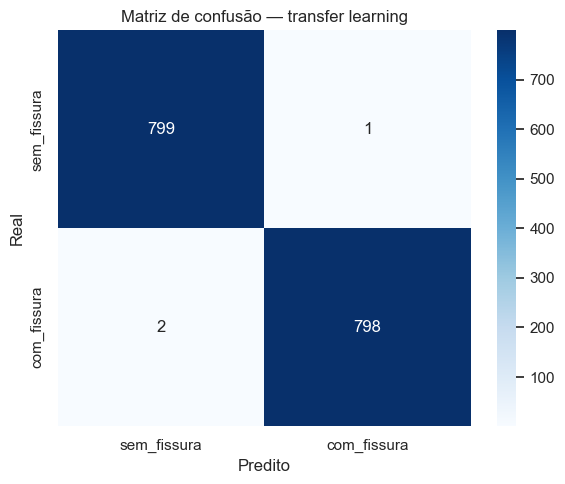

In [12]:
# Métricas finais (validação)
resultados_tl = avaliar_modelo_softmax(
    modelo_tl,
    X_valid,
    y_valid,
    nome_backbone=CONFIG["BACKBONE"],
    batch_size=CONFIG["BATCH_SIZE"],
    target_names=NOMES_CLASSES,
)
metricas_transfer = {
    "accuracy": resultados_tl["acuracia"],
    "f1_macro": resultados_tl["f1_macro"],
    "auc": resultados_tl["auc"],
}
print("Transfer learning:", metricas_transfer)

plt.figure(figsize=(6, 5))
sns.heatmap(
    resultados_tl["matriz_confusao"],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=list(NOMES_CLASSES),
    yticklabels=list(NOMES_CLASSES),
)
plt.title("Matriz de confusão — transfer learning")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()
plt.show()


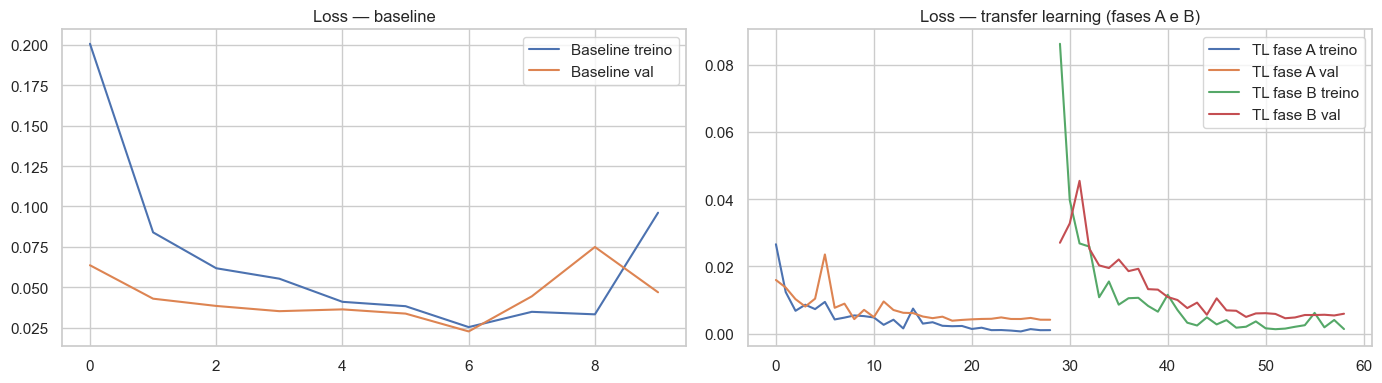

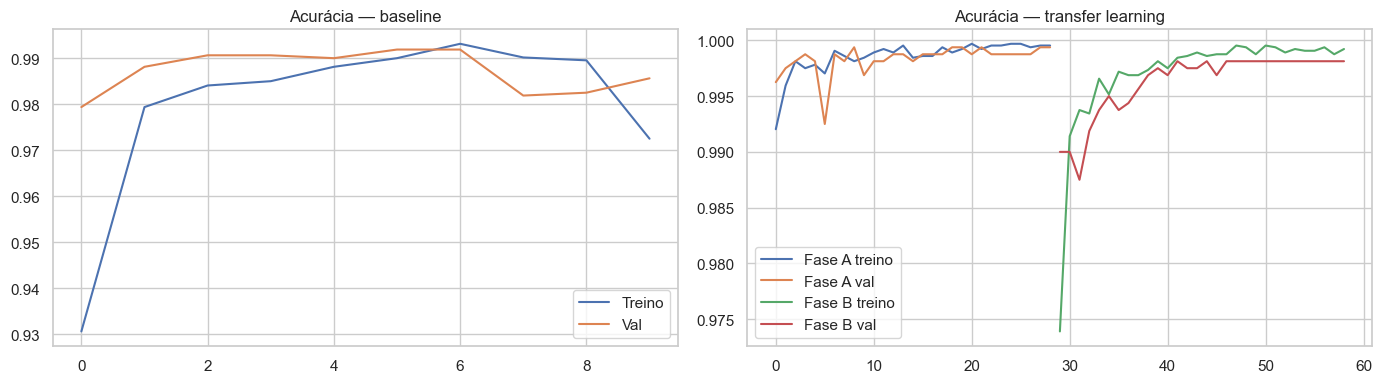

In [13]:
# Curvas loss e acurácia (baseline + transfer)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(historico_baseline.history["loss"], label="Baseline treino")
axes[0].plot(historico_baseline.history["val_loss"], label="Baseline val")
axes[0].set_title("Loss — baseline")
axes[0].legend()

ep1 = len(hist1.history["loss"])
axes[1].plot(range(ep1), hist1.history["loss"], label="TL fase A treino")
axes[1].plot(range(ep1), hist1.history["val_loss"], label="TL fase A val")
off = ep1
axes[1].plot(range(off, off + len(hist2.history["loss"])), hist2.history["loss"], label="TL fase B treino")
axes[1].plot(range(off, off + len(hist2.history["val_loss"])), hist2.history["val_loss"], label="TL fase B val")
axes[1].set_title("Loss — transfer learning (fases A e B)")
axes[1].legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(historico_baseline.history["accuracy"], label="Treino")
axes[0].plot(historico_baseline.history["val_accuracy"], label="Val")
axes[0].set_title("Acurácia — baseline")
axes[0].legend()

axes[1].plot(range(ep1), hist1.history["accuracy"], label="Fase A treino")
axes[1].plot(range(ep1), hist1.history["val_accuracy"], label="Fase A val")
axes[1].plot(range(off, off + len(hist2.history["loss"])), hist2.history["accuracy"], label="Fase B treino")
axes[1].plot(range(off, off + len(hist2.history["val_accuracy"])), hist2.history["val_accuracy"], label="Fase B val")
axes[1].set_title("Acurácia — transfer learning")
axes[1].legend()
plt.tight_layout()
plt.show()


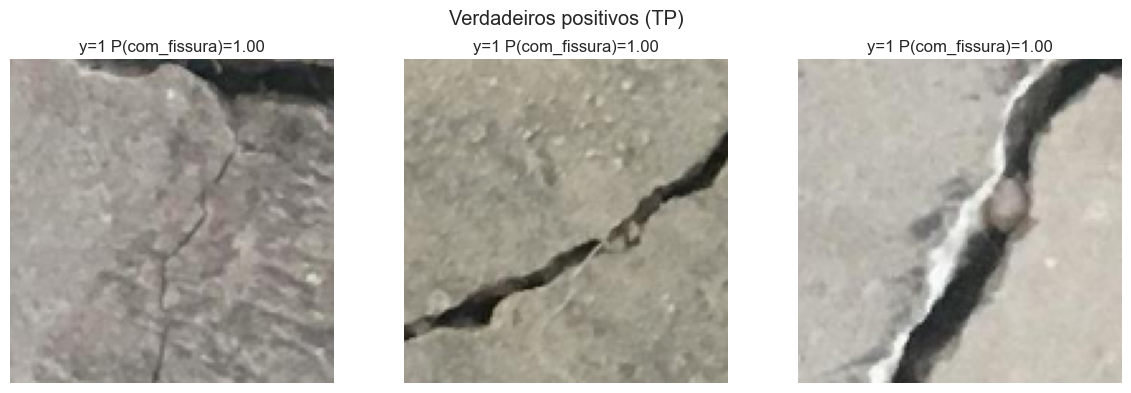

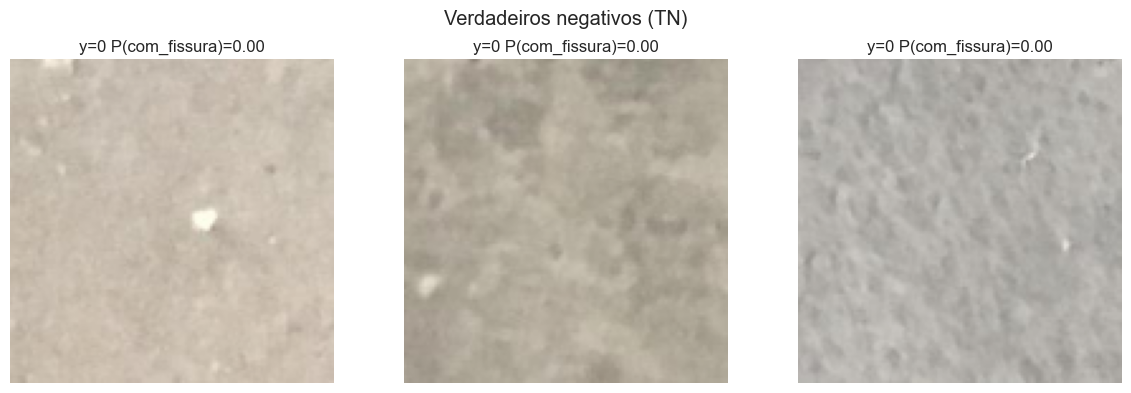

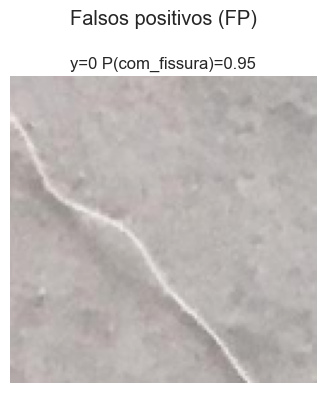

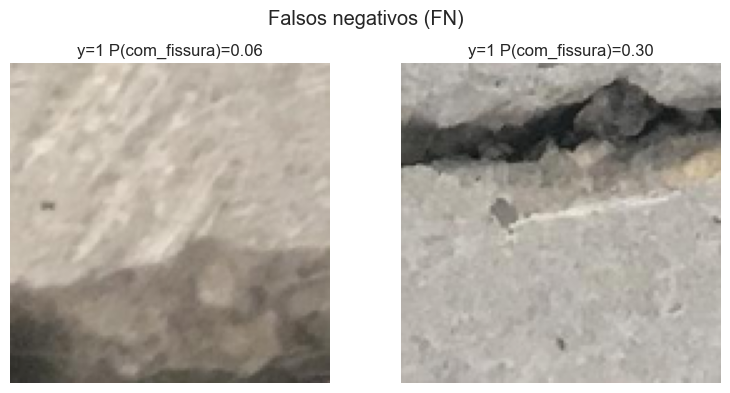

In [14]:
# Acertos e erros na validação (rótulo 1 = com fissura)
preds = resultados_tl["predicoes"]
probs_pos = resultados_tl["probabilidades_positivo"]

tp = np.where((y_valid == 1) & (preds == 1))[0]
tn = np.where((y_valid == 0) & (preds == 0))[0]
fp = np.where((y_valid == 0) & (preds == 1))[0]
fn = np.where((y_valid == 1) & (preds == 0))[0]


def _mostrar(indices, titulo, n=3):
    if len(indices) == 0:
        print(titulo, ": nenhum exemplo")
        return
    fig, axes = plt.subplots(1, min(n, len(indices)), figsize=(4 * min(n, len(indices)), 4))
    axes = np.atleast_1d(axes)
    for ax, idx in zip(axes, indices[:n]):
        ax.imshow(X_valid[idx])
        ax.set_title(f"y={y_valid[idx]} P(com_fissura)={probs_pos[idx]:.2f}")
        ax.axis("off")
    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()


_mostrar(tp, "Verdadeiros positivos (TP)")
_mostrar(tn, "Verdadeiros negativos (TN)")
_mostrar(fp, "Falsos positivos (FP)")
_mostrar(fn, "Falsos negativos (FN)")


In [15]:
# Grad-CAM (MobileNetV2)
if CONFIG["USE_GRADCAM"] and "mobilenet" in CONFIG["BACKBONE"].lower():
    idx = int(tp[0]) if len(tp) > 0 else 0
    x_pp = preprocess_numpy_rgb_01(np.expand_dims(X_valid[idx], 0), CONFIG["BACKBONE"])
    try:
        heat = grad_cam_mobilenet(modelo_tl, x_pp[0], classe_idx=1)
        plt.figure(figsize=(6, 4))
        plt.imshow(X_valid[idx])
        plt.imshow(heat, cmap="jet", alpha=0.35)
        plt.title("Grad-CAM (classe com fissura)")
        plt.axis("off")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("Grad-CAM omitido:", e)
else:
    print("Grad-CAM desligado ou backbone não MobileNetV2.")


Grad-CAM omitido: 'ReLU' object has no attribute 'output_shape'


## Conclusão executiva

Após executar o notebook, registre:

- **Acurácia de validação (transfer)** em `metricas_transfer` *vs.* **baseline** em `metricas_baseline`.
- **Interpretação:** AUC elevado indica boa separação entre superfície íntegra e com fissura no conjunto de validação.
- **Próximos passos:** validação em imagens de campo (outra câmera/iluminação), aumento de `MAX_IMAGENS_POR_CLASSE` ou pipeline baseado em arquivos se quiser usar as ~40k imagens completas sem carregar tudo na RAM.

**Artefatos:** `outputs/results_surface_crack.csv`, `models/surface_crack_transfer_phase1_best.keras`, `models/surface_crack_transfer_phase2_best.keras`.


In [16]:
# Inferência em arquivo único


def predizer_caminho_imagem(
    caminho: Path | str, modelo: tf.keras.Model, nome_backbone: str
) -> tuple[str, float]:
    cv2 = obter_cv2()
    caminho = Path(caminho)
    img_bgr = cv2.imread(str(caminho))
    if img_bgr is None:
        raise FileNotFoundError(caminho)
    img_bgr = cv2.resize(img_bgr, (IMG_W, IMG_H))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    batch = np.expand_dims(img_rgb, 0)
    x = preprocess_numpy_rgb_01(batch, nome_backbone)
    prob = modelo.predict(x, verbose=0)[0]
    rotulo = int(np.argmax(prob))
    prob_fissura = float(prob[1])
    nome_classe = NOMES_CLASSES[rotulo]
    return nome_classe, prob_fissura


_demo = CONFIG["DEMO_IMAGE"]
if _demo is not None and Path(_demo).is_file():
    cls, p = predizer_caminho_imagem(_demo, modelo_tl, CONFIG["BACKBONE"])
    print(f"Arquivo: {_demo} -> {cls} (P(com_fissura)={p:.4f})")
else:
    print("Defina CONFIG['DEMO_IMAGE'] para testar inferência em arquivo único.")


Defina CONFIG['DEMO_IMAGE'] para testar inferência em arquivo único.


### Teste com imagens reais

In [17]:
from pathlib import Path

# Ajuste para uma imagem do seu disco ou do dataset, por exemplo:
# minha_foto = Path(CONFIG["DATA_ROOT"]) / "surface-crack-detection" / "Positive" / "00132.jpg"
minha_foto = Path(CONFIG["DATA_ROOT"]) / "surface-crack-detection" / "Positive" / "00132.jpg"

if minha_foto.is_file():
    classe, prob = predizer_caminho_imagem(minha_foto, modelo_tl, CONFIG["BACKBONE"])
    print(f"Classe: {classe} | P(com_fissura) = {prob:.4f}")
else:
    print(f"Arquivo não encontrado: {minha_foto}. Ajuste o caminho em minha_foto.")


2026-04-03 16:11:57.666618: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Classe: com_fissura | P(com_fissura) = 1.0000
